## Importing the libraries

In [3]:
import pandas as pd
import numpy as np
import keras
from ucimlrepo import fetch_ucirepo

## Install and Print the dataset

In [31]:
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
df=pd.DataFrame(data=abalone.data.features) #, columns=abalone.variables.feature_names)  
print(df.head())
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables)

  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  
0         0.150  
1         0.070  
2         0.210  
3         0.155  
4         0.055  
{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical',

## One-Hot Encoding + Correlation Mapp

In [34]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output = False, drop=None)  # sparse=False per array denso
ohe = enc.fit_transform(df[['Sex']])
cols = [f"sex_{cat}" for cat in enc.categories_[0]]
df_ohe = pd.concat([df.drop(columns=['Sex']).reset_index(drop=True),
                    pd.DataFrame(ohe, columns=cols)], axis=1)

print(df_ohe.info())


<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          4177 non-null   float64
 1   Diameter        4177 non-null   float64
 2   Height          4177 non-null   float64
 3   Whole_weight    4177 non-null   float64
 4   Shucked_weight  4177 non-null   float64
 5   Viscera_weight  4177 non-null   float64
 6   Shell_weight    4177 non-null   float64
 7   sex_F           4177 non-null   float64
 8   sex_I           4177 non-null   float64
 9   sex_M           4177 non-null   float64
dtypes: float64(10)
memory usage: 326.5 KB
None


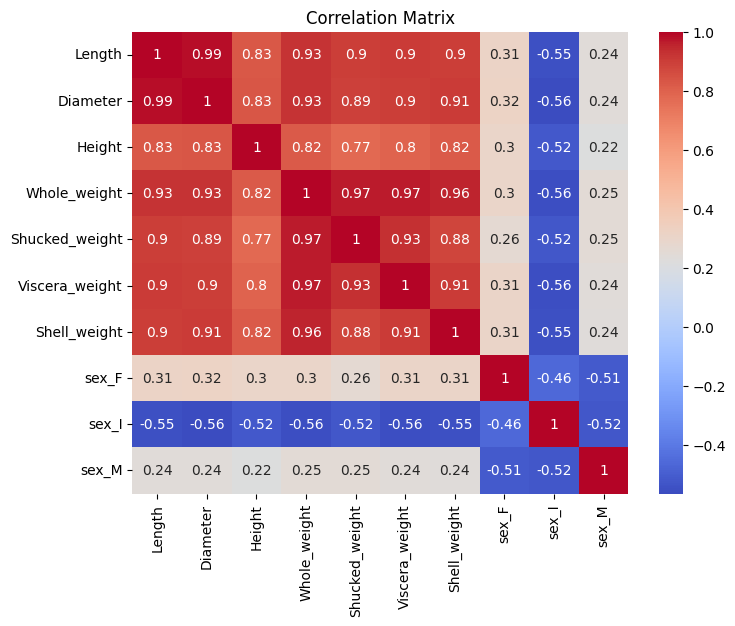

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


corr = df_ohe.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



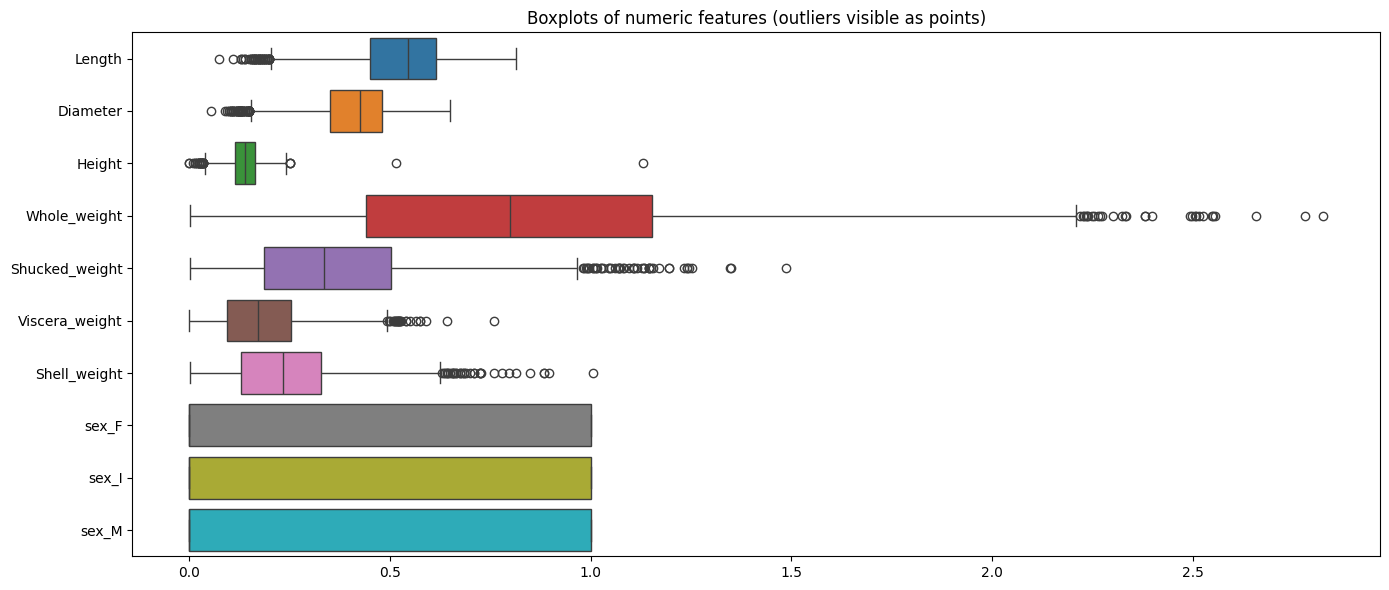

In [28]:
num_cols = df_ohe.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_ohe[num_cols], orient="h")
plt.title("Boxplots of numeric features (outliers visible as points)")
plt.tight_layout()
plt.show()

In [39]:
# Outlier detection and removal using IQR method
num_cols = df_ohe.select_dtypes(include=[np.number]).columns

def drop_outliers_iqr(df, k=1.5, cols=None):
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns

    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    mask_outlier = (df[cols] < lower) | (df[cols] > upper)
    rows_to_drop = mask_outlier.any(axis=1)

    return df.loc[~rows_to_drop].copy(), rows_to_drop

X_no_out, dropped_mask = drop_outliers_iqr(df_ohe, k=1.5, cols=num_cols)

# IMPORTANT: drop the same rows from y
y_no_out = y.loc[X_no_out.index]

print("Original rows:", len(df_ohe))
print("After IQR drop:", len(X_no_out))
print("Dropped rows:", dropped_mask.sum())

df_ohe = X_no_out
y = y_no_out

Original rows: 4177
After IQR drop: 4024
Dropped rows: 153


In [43]:
# no futher feature engineering: keep all features (best results)   
X = df_ohe

# # feature engineering: drop some features (not good)
# df =df_ohe.drop(columns=['Shucked_weight', 'Viscera_weight', 'Shell_weight'])
# X=df

# # feature engineering: drop 'Whole_weight'
# df2 = df_ohe.drop(columns=['Whole_weight'])
# X= df2

# # feature engineering: 1 st approach: ratios (not good)
# df3 = df_ohe.copy()
# df3['shucked_ratio'] = df_ohe['Shucked_weight'] / df_ohe['Whole_weight']
# df3['viscera_ratio'] = df_ohe['Viscera_weight'] / df_ohe['Whole_weight']
# df3['shell_ratio'] = df_ohe['Shell_weight'] / df_ohe['Whole_weight']
# df3 = df3.drop(columns=['Shucked_weight', 'Viscera_weight', 'Shell_weight'])
# X= df3

# # feature engineering: 2nd approach: density (good but not good as the original features)
# df4 = df_ohe.copy()
# eps= 1e-10
# df4['density'] = df_ohe['Whole_weight'] / (df_ohe['Length'] * df_ohe['Diameter'] * df_ohe['Height']+eps)
# df4['density'] = df4['density'].replace([np.inf, -np.inf], np.nan) # Gestisce divisioni per zero
# df4['density'] = df4['density'].dropna()  
# print(df4['density'].isna().sum())  # Verifica se ci sono valori NaN
# df4 = df4.drop(columns=['Whole_weight'])
# X = df4 


## Scaling and Splitting

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

## Linear Regression

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def poly_regression(X_train, X_test, y_train, y_test, degree=2, alpha=1.0, model = LinearRegression()):
    
    poly_lr = Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", model)
    ])

    poly_lr.fit(X_train, y_train)
    y_pred = poly_lr.predict(X_test)

    print("Poly LR")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 :", r2_score(y_test, y_pred))


def ridge_regression(X_train, X_test, y_train, y_test, alpha=1.0):

    #X = data.drop(columns=[target_column])
    #y = data[target_column]

    ridge_pipeline = Pipeline([
        ('model', Ridge(alpha))
    ])

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)

    model = ridge_pipeline.named_steps['model']
    mse = mean_squared_error(y_test, y_pred)

    print("Ridge (pipeline)")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print("R²:", r2_score(y_test, y_pred))
    print("Coefficienti:", model.coef_)
    print("Intercetta:", model.intercept_)

    return ridge_pipeline


def lasso_regression(X_train, X_test, y_train, y_test, alpha=0.1):

    lasso_pipeline = Pipeline([
        ('model', Lasso(alpha))
    ])

    lasso_pipeline.fit(X_train, y_train)
    y_pred = lasso_pipeline.predict(X_test)

    model = lasso_pipeline.named_steps['model']
    mse = mean_squared_error(y_test, y_pred)

    print("Lasso (pipeline)")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print("R²:", r2_score(y_test, y_pred))
    print("Coefficienti:", model.coef_)
    print("Intercetta:", model.intercept_)

    return lasso_pipeline

In [46]:
model1 = ridge_regression(X_train, X_test, y_train, y_test) # Mean Squared Error (MSE): 5.1651, R²: 0.5228595693604992

# model2 = lasso_regression(X_train, X_test, y_train, y_test) # Mean Squared Error (MSE): 6.8472 R²: 0.3674744021854117

model3 = ridge_regression(X_train, X_test, y_train, y_test, alpha=0.0)
# model4 = ridge_regression(X_train, X_test, y_train, y_test, alpha=0.5)
# model5 = ridge_regression(X_train, X_test, y_train, y_test, alpha=2.0)
model6 = poly_regression(X_train, X_test, y_train, y_test, degree=2) # Poly LR -> MSE: 5.037440046549578, R2 : 0.534656600162983
model7 = poly_regression(X_train, X_test, y_train, y_test, degree=2, model=Ridge(alpha=1.0))  #Poly LR -> MSE: 4.996392755077494, R2 : 0.5384484241829648

Ridge (pipeline)
Mean Squared Error (MSE): 5.1203
R²: 0.5119146279957332
Coefficienti: [  1.59377213   5.43583338   9.60223598   6.80863341 -17.61648892
  -7.51858457  12.6491806    0.33109602  -0.64817831   0.3170823 ]
Intercetta: [4.56253048]
Ridge (pipeline)
Mean Squared Error (MSE): 5.0009
R²: 0.5232928306713851
Coefficienti: [-2.57469104e+00  9.56760558e+00  2.13333935e+01  9.15876853e+00
 -2.06407762e+01 -1.21547889e+01  1.06383023e+01 -3.70024579e+14
 -3.70024579e+14 -3.70024579e+14]
Intercetta: [3.70024579e+14]
Poly LR
MSE: 4.621837950322899
R2 : 0.5594294366149992
Poly LR
MSE: 4.838063482061771
R2 : 0.5388180250163384


## Neural Network

In [47]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # forza CPU

import tensorflow as tf
print("GPU visibili:", tf.config.list_physical_devices("GPU"))

# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(9,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


#NN  -> MSE: 4.928940, R2: 0.544680
#Poly LR -> MSE: 4.996392755077494, R2 : 0.5384484241829648

#NN  -> MSE: 4.767396, R2: 0.559602
#Poly LR -> MSE: 4.996392755077494, R2 : 0.5384484241829648

#NN  -> MSE: 4.748704, R2: 0.561329
#Poly LR -> MSE: 4.996392755077494, R2 : 0.5384484241829648

GPU visibili: []


In [11]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # forza CPU

import tensorflow as tf
print("GPU visibili:", tf.config.list_physical_devices("GPU"))

# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(9,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

GPU visibili: []


In [51]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # forza CPU

import tensorflow as tf
print("GPU visibili:", tf.config.list_physical_devices("GPU"))

# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(10,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

GPU visibili: []


In [52]:
# build the model
model = regression_model()


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=1000,
    verbose=2,
    callbacks=[early_stop]
)
min_val_loss = np.min(history.history["val_loss"])

print("Min val_loss:", min_val_loss)

# 3) predizioni della rete sul test set
y_pred_nn = model.predict(X_test).ravel()

# 4) fit regressione lineare (esempio con scikit-learn) sui medesimi X_train/y_train
from sklearn.linear_model import LinearRegression
lr = model6
y_pred_lr = lr.predict(X_test).ravel()

# 5) metriche
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn  = r2_score(y_test, y_pred_nn)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print(f"NN  -> MSE: {mse_nn:.6f}, R2: {r2_nn:.6f}")
print(f"LR  -> MSE: {mse_lr:.6f}, R2: {r2_lr:.6f}")

Epoch 1/1000
71/71 - 17s - 241ms/step - loss: 71.6800 - val_loss: 12.9285
Epoch 2/1000
71/71 - 1s - 10ms/step - loss: 7.9927 - val_loss: 7.2903
Epoch 3/1000
71/71 - 2s - 23ms/step - loss: 6.9188 - val_loss: 6.7573
Epoch 4/1000
71/71 - 1s - 12ms/step - loss: 6.5380 - val_loss: 6.4832
Epoch 5/1000
71/71 - 1s - 16ms/step - loss: 6.2595 - val_loss: 6.1188
Epoch 6/1000
71/71 - 3s - 39ms/step - loss: 6.1324 - val_loss: 5.9658
Epoch 7/1000
71/71 - 2s - 29ms/step - loss: 5.9845 - val_loss: 5.8585
Epoch 8/1000
71/71 - 1s - 12ms/step - loss: 5.9010 - val_loss: 5.7331
Epoch 9/1000
71/71 - 1s - 14ms/step - loss: 5.7701 - val_loss: 5.5771
Epoch 10/1000
71/71 - 1s - 14ms/step - loss: 5.6659 - val_loss: 5.4437
Epoch 11/1000
71/71 - 1s - 13ms/step - loss: 5.5866 - val_loss: 5.3806
Epoch 12/1000
71/71 - 0s - 5ms/step - loss: 5.4185 - val_loss: 5.2269
Epoch 13/1000
71/71 - 2s - 23ms/step - loss: 5.2694 - val_loss: 5.0601
Epoch 14/1000
71/71 - 1s - 11ms/step - loss: 5.1746 - val_loss: 4.9760
Epoch 15/100